In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
#import dtreeviz
import matplotlib.pyplot as plt

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

feature_names = cancer.feature_names
class_names = list(cancer.target_names) # ['malignant', 'benign']

print(f"Feature Names: {feature_names}")
print(f"Class Names: {class_names}")
print(f"Data Shape: {X.shape}")

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Class Names: [np.str_('malignant'), np.str_('benign')]
Data Shape: (569, 30)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [4]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Model Accuracy: 96.49%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.94      0.95        63
      benign       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



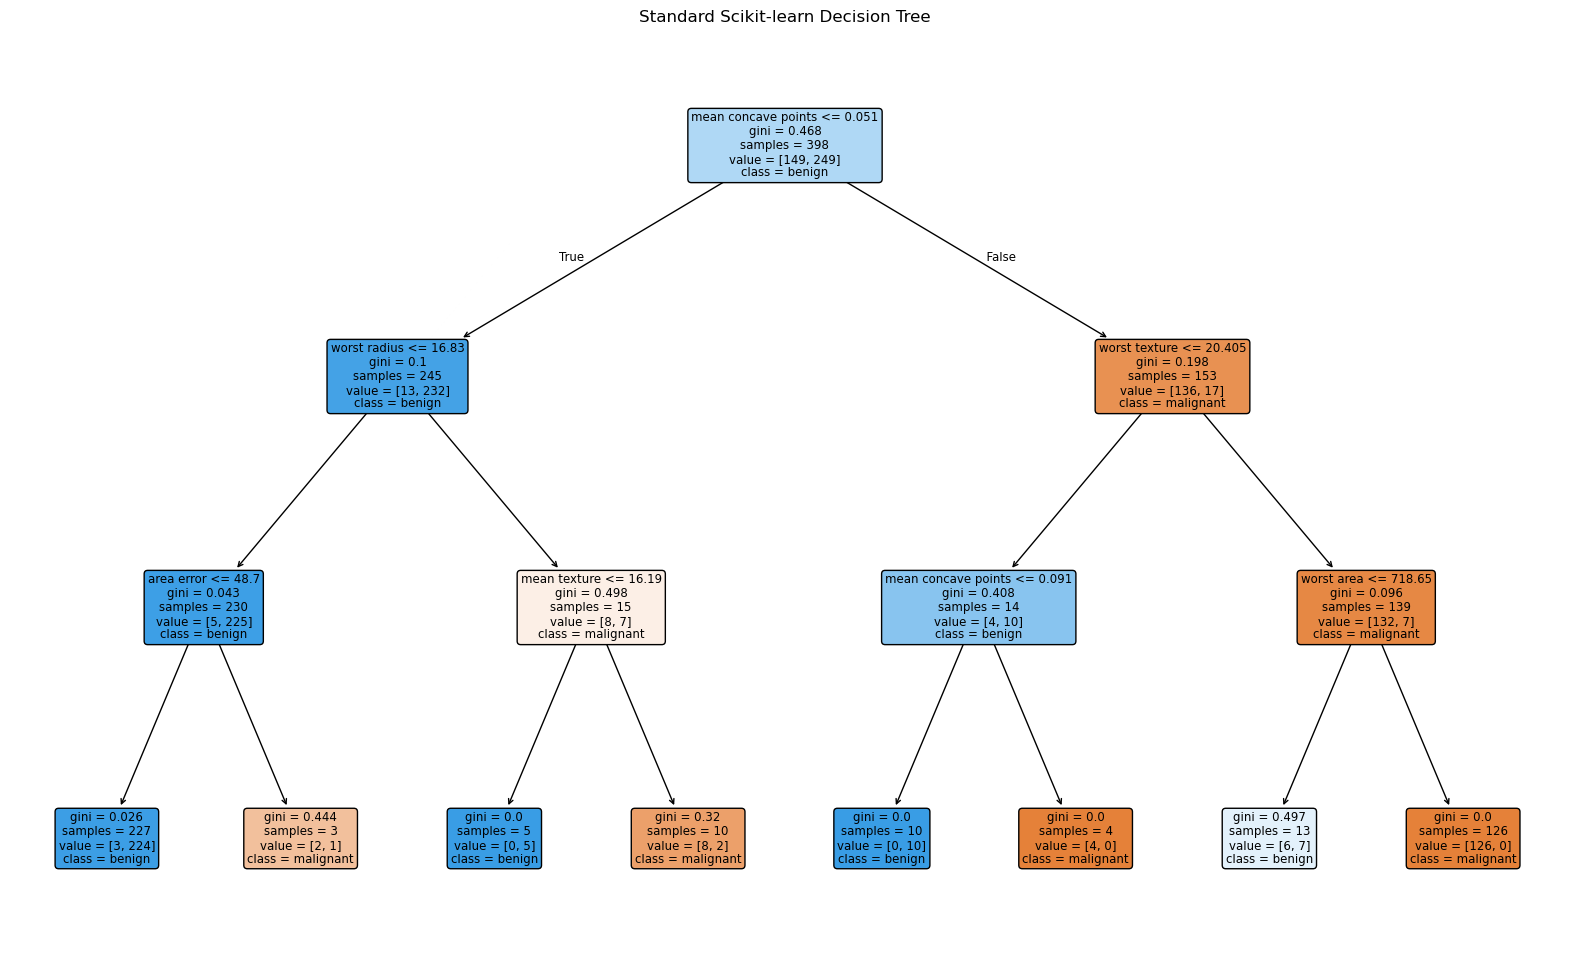

In [6]:
plt.figure(figsize=(20, 12))
plot_tree(clf,
          filled=True,
          rounded=True,
          class_names=class_names,
          feature_names=feature_names)
plt.title("Standard Scikit-learn Decision Tree")
plt.show()

In [5]:
# viz_model = dtreeviz.model(clf,
#                            X_train=X_train,
#                            y_train=y_train,
#                            feature_names=feature_names,
#                            target_name='Tumor Type',
#                            class_names=class_names)

# v = viz_model.view(scale=1.0) 
# v.show()